In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check if CUDA is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")


Using device: cuda
PyTorch version: 2.8.0+cu128


In [2]:


# 1. Load dataset
# ipynb 파일과 같은 경로에 있는 csv 파일을 읽어옵니다.
data = pd.read_csv("London Property Listings Dataset.csv")

# 2. Extract features and target
# 캘리포니아 데이터셋과 달리, CSV는 타겟('Price')을 직접 분리해야 합니다.
if 'Price' in data.columns:
    y = data['Price']                  # Target
    X = data.drop('Price', axis=1)     # Features (Price 제외)
else:
    # 혹시 Price 컬럼이 없을 경우를 대비한 예외 처리 (일반적으로 첫 번째 열이 타겟일 수 있음)
    y = data.iloc[:, 0]
    X = data.iloc[:, 1:]

print("Dataset Information:")
print(f"Number of samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")
# data.feature_names 대신 X.columns를 사용합니다.
print(f"\nFeature names: {list(X.columns)}") 
print(f"Target: Price (Actual Value in GBP)")

# 3. Display statistics
# 주의: 캘리포니아 데이터와 달리 이 데이터는 이미 실제 가격 단위이므로 * 100000을 제거했습니다.
print(f"\nTarget statistics:")
print(f"  Min: £{y.min():,.2f}")
print(f"  Max: £{y.max():,.2f}")
print(f"  Mean: £{y.mean():,.2f}")

Dataset Information:
Number of samples: 29537
Number of features: 8

Feature names: ['Property Type', 'Bedrooms', 'Bathrooms', 'Size', 'Postcode', 'Area', 'Price_Category', 'Area_Avg_Price']
Target: Price (Actual Value in GBP)

Target statistics:
  Min: £65,000.00
  Max: £5,950,000.00
  Mean: £965,235.46


In [4]:
# 1. 문자열(Object) 타입의 컬럼을 모두 찾아서 원-핫 인코딩(숫자로 변환) 합니다.
# drop_first=True는 다중공선성 문제를 피하기 위해 첫 번째 카테고리는 생략하는 옵션입니다.
X = pd.get_dummies(X, drop_first=True)

print("Encoded X shape:", X.shape)
# 이제 X에는 숫자만 들어있습니다.

# 2. 데이터 분할 (이후 코드는 동일)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. 스케일링 진행 (이제 에러가 나지 않습니다)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n✓ Data normalized (mean=0, std=1)")

Encoded X shape: (29537, 241)

✓ Data normalized (mean=0, std=1)


In [15]:
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler

# 1. y(Target) 전용 스케일러 생성 및 적용 (가장 중요!)
y_scaler = StandardScaler()
# .values를 쓴 뒤 reshape를 해서 스케일러에 넣습니다.
y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = y_scaler.transform(y_test.values.reshape(-1, 1))

# 2. PyTorch 텐서로 변환 (이제 스케일링된 작고 예쁜 숫자가 들어갑니다)
X_train_tensor = torch.FloatTensor(X_train_scaled)
y_train_tensor = torch.FloatTensor(y_train_scaled) # <--- 수정됨

X_test_tensor = torch.FloatTensor(X_test_scaled)
y_test_tensor = torch.FloatTensor(y_test_scaled)   # <--- 수정됨

# 3. 데이터셋 생성 (동일)
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# 4. 데이터로더 생성 (배치 사이즈 64 유지)
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Batch size: {batch_size}")
print("데이터 준비 완료! (Target Scaling 적용됨)")

Batch size: 64
데이터 준비 완료! (Target Scaling 적용됨)


In [16]:
class RegressionModel(nn.Module):
    def __init__(self, input_size, hidden_size1=64, hidden_size2=32):
        super(RegressionModel, self).__init__()
        
        # Define layers
        self.fc1 = nn.Linear(input_size, hidden_size1)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size1, hidden_size2)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(hidden_size2, 1)  # Output layer
        
    def forward(self, x):
        # Forward pass through the network
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        return x

# Initialize model
input_size = X_train_scaled.shape[1]  # Number of features (8)
model = RegressionModel(input_size).to(device)

print(model)
print(f"\nModel moved to: {device}")

RegressionModel(
  (fc1): Linear(in_features=241, out_features=64, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=32, out_features=1, bias=True)
)

Model moved to: cuda


In [17]:
# Loss function: Mean Squared Error
criterion = nn.MSELoss()

# Optimizer: Adam with learning rate 0.001
learning_rate = 0.001
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

print(f"Loss function: {criterion}")
print(f"Optimizer: Adam")
print(f"Learning rate: {learning_rate}")

Loss function: MSELoss()
Optimizer: Adam
Learning rate: 0.001


In [18]:
# 1. y(Target) 전용 스케일러를 따로 만듭니다.
y_scaler = StandardScaler()

# 2. y 데이터를 2차원 배열로 변환 후 스케일링
# fit_transform은 2차원([n_samples, 1])을 기대하므로 reshape(-1, 1)이 필요합니다.
y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = y_scaler.transform(y_test.values.reshape(-1, 1))

# 3. 텐서로 변환 (이제 스케일링된 데이터를 사용)
X_train_tensor = torch.FloatTensor(X_train_scaled)
y_train_tensor = torch.FloatTensor(y_train_scaled) # 스케일된 y 사용

X_test_tensor = torch.FloatTensor(X_test_scaled)
y_test_tensor = torch.FloatTensor(y_test_scaled)   # 스케일된 y 사용

# ... (이후 DataLoader 및 학습 코드는 동일) ...

# Training parameters
num_epochs = 100

# Track losses for visualization
train_losses = []
test_losses = []

print("Starting training...")
print("-" * 60)

for epoch in range(num_epochs):
    # Training phase
    model.train()
    train_loss = 0.0
    
    for X_batch, y_batch in train_loader:
        # Move data to device (GPU if available)
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        # 1. Forward pass: compute predictions
        predictions = model(X_batch)
        
        # 2. Compute loss
        loss = criterion(predictions, y_batch)
        
        # 3. Backward pass: compute gradients
        optimizer.zero_grad()  # Clear previous gradients
        loss.backward()  # Compute new gradients
        
        # 4. Update weights
        optimizer.step()
        
        train_loss += loss.item()
    
    # Average training loss for this epoch
    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # Evaluation phase (no gradient computation needed)
    model.eval()
    test_loss = 0.0
    
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)
            test_loss += loss.item()
    
    avg_test_loss = test_loss / len(test_loader)
    test_losses.append(avg_test_loss)
    
    # Print progress every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] | "
              f"Train Loss: {avg_train_loss:.4f} | "
              f"Test Loss: {avg_test_loss:.4f}")

print("-" * 60)
print("Training complete!")

Starting training...
------------------------------------------------------------
Epoch [10/100] | Train Loss: 0.1148 | Test Loss: 0.1418
Epoch [20/100] | Train Loss: 0.1043 | Test Loss: 0.1170
Epoch [30/100] | Train Loss: 0.0972 | Test Loss: 0.1213
Epoch [40/100] | Train Loss: 0.0922 | Test Loss: 0.1145
Epoch [50/100] | Train Loss: 0.0902 | Test Loss: 0.1127
Epoch [60/100] | Train Loss: 0.0887 | Test Loss: 0.1111
Epoch [70/100] | Train Loss: 0.0836 | Test Loss: 0.1180
Epoch [80/100] | Train Loss: 0.0828 | Test Loss: 0.1139
Epoch [90/100] | Train Loss: 0.0812 | Test Loss: 0.1131
Epoch [100/100] | Train Loss: 0.0793 | Test Loss: 0.1143
------------------------------------------------------------
Training complete!


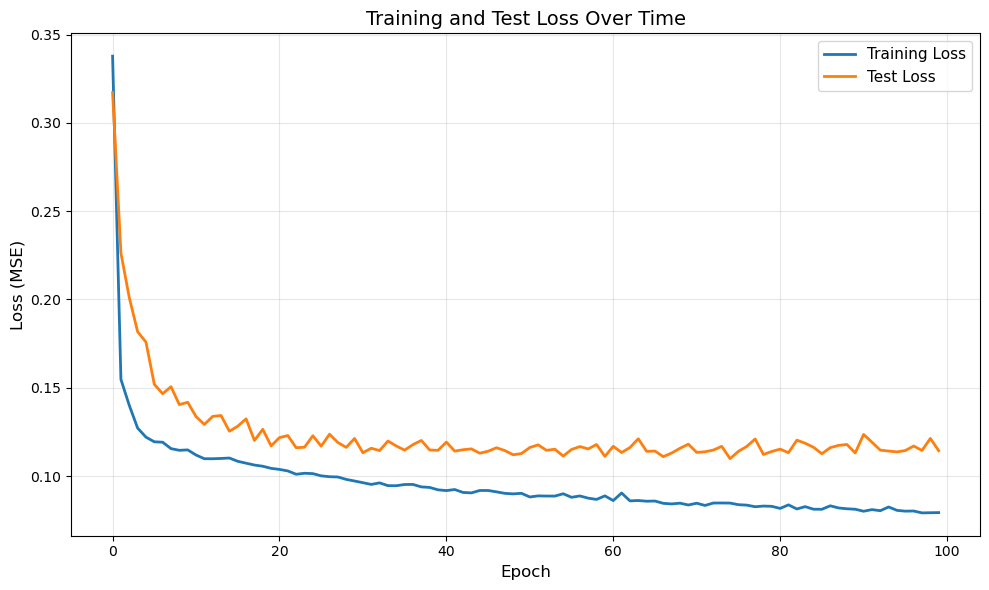

Final Training Loss: 0.0793
Final Test Loss: 0.1143


In [19]:
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss', linewidth=2)
plt.plot(test_losses, label='Test Loss', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.title('Training and Test Loss Over Time', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final Training Loss: {train_losses[-1]:.4f}")
print(f"Final Test Loss: {test_losses[-1]:.4f}")

In [20]:
# Make predictions on test set
model.eval()
with torch.no_grad():
    X_test_device = X_test_tensor.to(device)
    y_pred = model(X_test_device).cpu().numpy()
    y_true = y_test_tensor.numpy()

# Calculate metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)
rmse = np.sqrt(mse)

print("Model Performance on Test Set:")
print("=" * 50)
print(f"Mean Squared Error (MSE):  {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R² Score: {r2:.4f}")
print("=" * 50)
print(f"\nInterpretation:")
print(f"On average, predictions are off by ${mae * 100000:.2f}")
print(f"Model explains {r2*100:.2f}% of the variance in house prices")

Model Performance on Test Set:
Mean Squared Error (MSE):  0.1149
Root Mean Squared Error (RMSE): 0.3390
Mean Absolute Error (MAE): 0.1932
R² Score: 0.8894

Interpretation:
On average, predictions are off by $19319.96
Model explains 88.94% of the variance in house prices


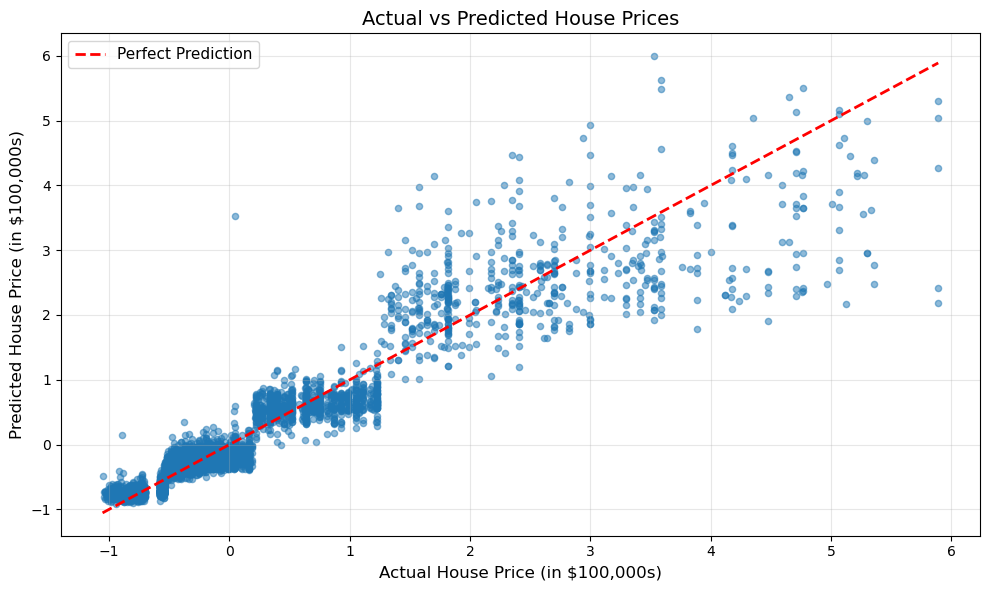


Sample Predictions (first 10 houses):
------------------------------------------------------------
      Actual |    Predicted |   Difference
------------------------------------------------------------
$    16,215 | $    -5,436 | $    21,651
$   -28,075 | $   -21,247 | $    -6,827
$   -39,885 | $   -30,695 | $    -9,190
$     4,405 | $    -8,589 | $    12,994
$   -77,089 | $   -67,275 | $    -9,814
$   -51,106 | $   -29,117 | $   -21,989
$   -36,933 | $   -34,849 | $    -2,084
$   -35,161 | $   -31,906 | $    -3,255
$   -72,365 | $   -72,690 | $       325
$   101,489 | $    85,988 | $    15,500


In [21]:
# Create scatter plot of predictions vs actual values
plt.figure(figsize=(10, 6))
plt.scatter(y_true, y_pred, alpha=0.5, s=20)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual House Price (in $100,000s)', fontsize=12)
plt.ylabel('Predicted House Price (in $100,000s)', fontsize=12)
plt.title('Actual vs Predicted House Prices', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Show some sample predictions
print("\nSample Predictions (first 10 houses):")
print("-" * 60)
print(f"{'Actual':>12} | {'Predicted':>12} | {'Difference':>12}")
print("-" * 60)
for i in range(min(10, len(y_true))):
    actual = y_true[i][0] * 100000
    predicted = y_pred[i][0] * 100000
    diff = actual - predicted
    print(f"${actual:>10,.0f} | ${predicted:>10,.0f} | ${diff:>10,.0f}")